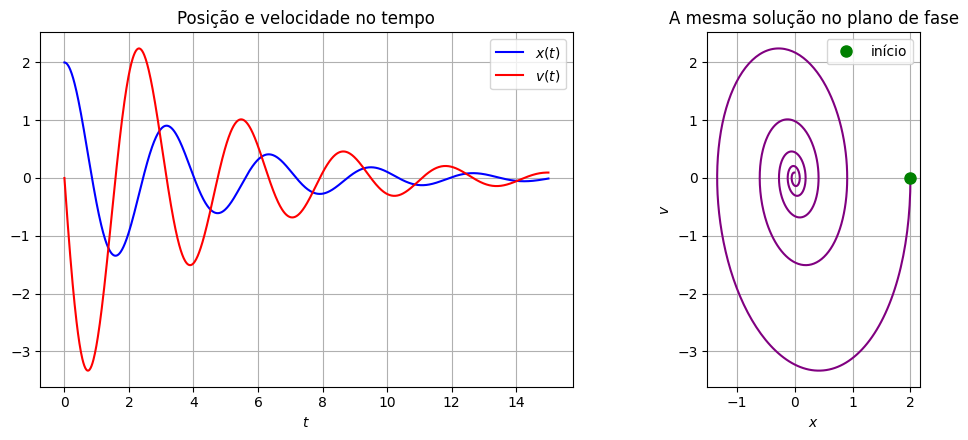

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

m, gamma, k = 1.0, 0.5, 4.0

def oscilador(t, estado):
    x, v = estado
    return [v, -(k/m)*x - (gamma/m)*v]

t = np.linspace(0, 15, 1000)
sol = solve_ivp(oscilador, (0, 15), [2, 0], t_eval=t)
x, v = sol.y

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].plot(t, x, 'b', label='$x(t)$')
axs[0].plot(t, v, 'r', label='$v(t)$')
axs[0].set_xlabel("$t$"); axs[0].legend(); axs[0].grid(True)
axs[0].set_title("Posição e velocidade no tempo")

axs[1].plot(x, v, 'purple')
axs[1].plot(x[0], v[0], 'go', markersize=8, label='início')
axs[1].set_xlabel("$x$"); axs[1].set_ylabel("$v$")
axs[1].set_title("A mesma solução no plano de fase")
axs[1].legend(); axs[1].grid(True)
axs[1].set_aspect('equal')
plt.tight_layout()
plt.show()

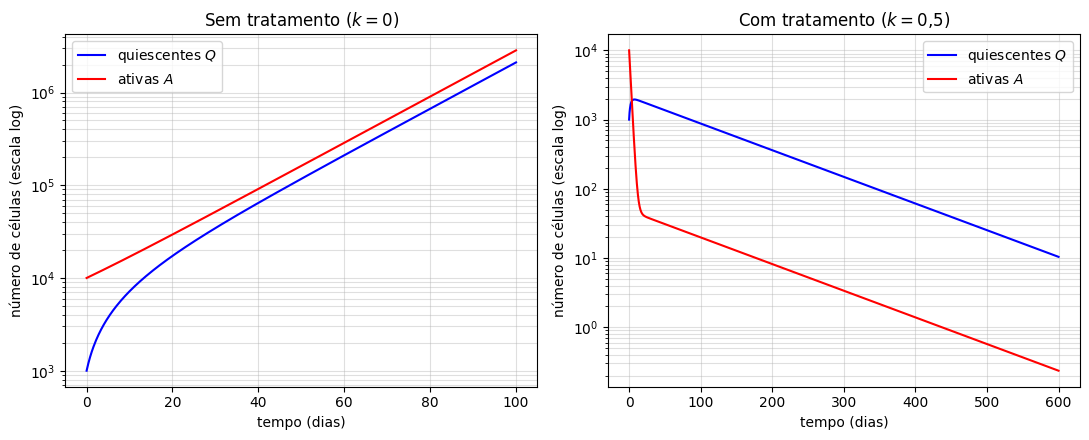

In [2]:
a, b, p = 0.01, 0.05, 0.1

def leucemia(t, estado, k):
    Q, A = estado
    return [-a*Q + b*A, a*Q - b*A + (p - k)*A]

t = np.linspace(0, 600, 2000)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

sol = solve_ivp(leucemia, (0, 100), [1e3, 1e4], t_eval=np.linspace(0, 100, 500), args=(0.0,))
axs[0].semilogy(sol.t, sol.y[0], 'b', label='quiescentes $Q$')
axs[0].semilogy(sol.t, sol.y[1], 'r', label='ativas $A$')
axs[0].set_title("Sem tratamento ($k=0$)")

sol = solve_ivp(leucemia, (0, 600), [1e3, 1e4], t_eval=t, args=(0.5,), rtol=1e-8, atol=1e-10)
axs[1].semilogy(sol.t, sol.y[0], 'b', label='quiescentes $Q$')
axs[1].semilogy(sol.t, sol.y[1], 'r', label='ativas $A$')
axs[1].set_title("Com tratamento ($k=0{,}5$)")

for ax in axs:
    ax.set_xlabel("tempo (dias)"); ax.set_ylabel("número de células (escala log)")
    ax.legend(); ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

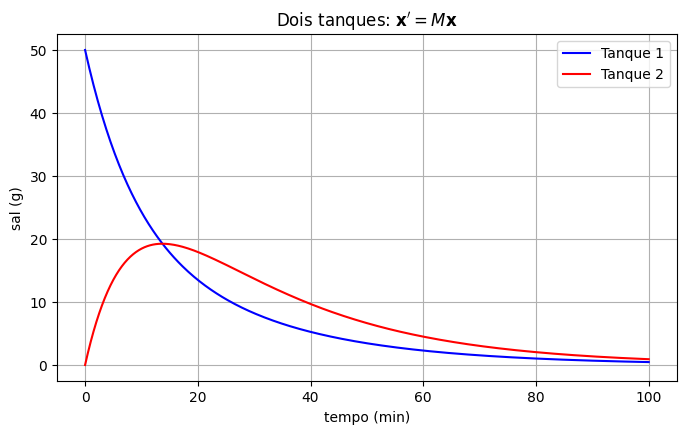

In [3]:
M = np.array([[-0.08, 0.02],
              [ 0.08, -0.08]])

def tanques(t, x):
    return M @ x          # o sistema inteiro numa linha: x' = M x

sol = solve_ivp(tanques, (0, 100), [50, 0], t_eval=np.linspace(0, 100, 400))
plt.figure(figsize=(8, 4.5))
plt.plot(sol.t, sol.y[0], 'b', label='Tanque 1')
plt.plot(sol.t, sol.y[1], 'r', label='Tanque 2')
plt.xlabel("tempo (min)"); plt.ylabel("sal (g)")
plt.title(r"Dois tanques: $\mathbf{x}' = M\mathbf{x}$")
plt.legend(); plt.grid(True)
plt.show()